# 18 — Urban Renewal Classification 城市更新 留-改-拆

**Core question**: How does Beijing's 城市更新 framework (留-改-拆) become a
computable classification task on a building-level GeoJSON site?

**Answer**: three independent lenses — rule-based physical scoring (M1),
spatial clustering for block coherence (M2), and FAR-capacity economics (M3).
M2 is the decision-implementation layer: it absorbs M1's isolated demolition
candidates so adjacent buildings share fate; M3 arbitrates by development
value. When methods conflict, Beijing's regulation principle 以保留利用提升为主
resolves toward the more conservative treatment.


## 0. Background — 留-改-拆 framework

《北京市城市更新条例》(2022年11月通过，2023年3月1日施行) 将城市更新
（对建成区内城市空间形态和功能进行的整治、改善、活化、提升活动）分为三类：

| 类别 | 中文 | 适用对象 |
|---|---|---|
| retain | 留 | 风貌完整、结构安全、使用功能正常 — 保留、整治、提升 |
| renovate | 改 | 功能衰退但结构可利用 — 改建、扩建、修缮、功能转换 |
| demolish | 拆 | 危旧楼房（鉴定危险且无修缮价值）、严重低效用地 — 拆除重建 |

条例确立的核心原则：**"留改拆"并举、以保留利用提升为主，防止大拆大建**，
采取小规模、渐进式、可持续的有机更新方式。

本 notebook 用三种方法对同一块模拟场地给出 留/改/拆 判定：

1. **Method 1 规则评分** — 按建筑年代、结构类型、用地匹配逐栋打分
2. **Method 2 空间聚类** — 相邻建筑同命运，禁止"独栋拆除"
3. **Method 3 容量评估** — 现状容积率 vs 规划容积率，判断开发价值

> 注：条例本身不规定 30 年 / 15 年等具体阈值。本 notebook 的阈值是演示用
> 参考值 —— 属参数敏感型（C 类）分析，正式使用时应与规划主管部门标定并
> 写入 assumptions.json。


## 1. Method 1 — Rule-based classification 规则评分

对每栋建筑按三个维度打分，`score = age_score + structure_score + mismatch_score`：

| 维度 | 条件 | 分值 |
|---|---|---|
| 建筑年代 age | >30 年 → 考虑拆除；15–30 年 → 整治改造；<15 年 → 保留 | 3 / 2 / 1 |
| 结构类型 structure | 砖混/砖木 (masonry) 弱；钢筋混凝土 (rc) 强 | 2 / 1 |
| 用地匹配 use | 现状用途 ≠ 规划用途 → 需要改造 | 1 / 0 |

判定：`score >= 5` → 拆；`3 <= score < 5` → 改；`score < 3` → 留。

危旧房（`unsafe=True`，鉴定危险且无修缮价值）直接判 拆 —— 条例中唯一
明确支持拆除重建的情形。


In [1]:
import sys
from pathlib import Path


def _repo_root():
    # Repo root = nearest ancestor containing both src/ and notebooks/.
    p = Path.cwd()
    while p != p.parent:
        if (p / "src").is_dir() and (p / "notebooks").is_dir():
            return p
        p = p.parent
    return Path.cwd()


ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from shapely.geometry import box

matplotlib.rcParams["font.sans-serif"] = [
    "PingFang SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False


In [2]:
# implementation extracted to src/renewal.py
from src.renewal import (
    TREATMENT_ZH,
    TREATMENT_ORDER,
    capacity_assessment,
    classify_building,
    score_to_treatment,
    spatial_cluster,
)


### 1.1 模拟场地

确定性合成场地 (seed=42)：4 个街区，每街区 4×4 = 16 栋建筑（20×20 m，
间距 10 m），街区之间 30 m 道路间隔；另加 1 栋 12×12 m 附属小建筑
（距 B0 东侧 8 m，与 B0 相邻）。街区建筑画像：

| 街区 | 年代 | 结构 | 用途失配率 | 层数 | 规划用途 |
|---|---|---|---|---|---|
| B0 | 8–20 年（较新） | 90% rc | 5% | 4–6 | residential |
| B1 | 16–28 年（中年） | 80% rc | 15% | 3–5 | residential |
| B2 | 32–50 年（老旧） | 15% rc (85% masonry) | 20% | 2–4 | mixed |
| B3 | 12–40 年（混杂） | 70% rc | 10% | 3–4 | commercial |


In [3]:
def build_site(seed=42):
    rng = np.random.default_rng(seed)
    uses = ["residential", "residential", "residential",
            "commercial", "mixed", "office"]
    planned_by_block = {"B0": "residential", "B1": "residential",
                        "B2": "mixed", "B3": "commercial"}
    profiles = [
        # name, origin, age_range, p_rc, p_mismatch, floors_range
        ("B0", (0, 0),     (8, 20), 0.90, 0.05, (4, 6)),
        ("B1", (150, 0),   (16, 28), 0.80, 0.15, (3, 5)),
        ("B2", (0, 150),   (32, 50), 0.15, 0.20, (2, 4)),
        ("B3", (150, 150), (12, 40), 0.70, 0.10, (3, 4)),
    ]
    buildings, records = [], []
    for name, (ox, oy), (a0, a1), p_rc, p_mis, (f0, f1) in profiles:
        planned = planned_by_block[name]
        for i in range(4):
            for j in range(4):
                x, y = ox + j * 30, oy + i * 30
                age = int(rng.integers(a0, a1 + 1))
                structure = "rc" if rng.random() < p_rc else "masonry"
                if rng.random() < p_mis:
                    current = rng.choice([u for u in uses if u != planned])
                else:
                    current = planned
                buildings.append(box(x, y, x + 20, y + 20))
                records.append(dict(
                    id=f"{name}-{i}{j}", block=name, kiosk=False, age=age,
                    structure=structure, current_use=current,
                    planned_use=planned, floors=int(rng.integers(f0, f1 + 1)),
                    unsafe=False))
    # 1 small 12x12 m outbuilding 8 m east of B0 -> adjacent to B0's cluster
    buildings.append(box(118, 20, 130, 32))
    records.append(dict(id="K0", block="B0", kiosk=True, age=10,
                        structure="rc", current_use="residential",
                        planned_use="residential", floors=1, unsafe=False))
    return buildings, records


buildings, records = build_site()


def counts(t):
    return {t_: int(np.sum(t == t_)) for t_ in TREATMENT_ORDER}


classed = [classify_building(r["age"], r["structure"], r["current_use"],
                             r["planned_use"], r["unsafe"])
           for r in records]
scores = np.array([c["score"] for c in classed])
treat_m1 = np.array([c["treatment"] for c in classed], dtype=object)
print(f"site: {len(buildings)} buildings (65 = 4 blocks x 16 + 1 kiosk)")
print("Method-1 counts:", counts(treat_m1))
print()
print("first 8 buildings (id, age, structure, use -> planned, floors, score -> 判定):")
for r, c in zip(records[:8], classed[:8]):
    print(f'  {r["id"]:<6} age={r["age"]:>2}  {r["structure"]:<8} '
          f'{r["current_use"]:<12}-> {r["planned_use"]:<12} '
          f'floors={r["floors"]:>2}  score={c["score"]} -> {TREATMENT_ZH[c["treatment"]]}')


site: 65 buildings (65 = 4 blocks x 16 + 1 kiosk)
Method-1 counts: {'retain': 7, 'renovate': 41, 'demolish': 17}

first 8 buildings (id, age, structure, use -> planned, floors, score -> 判定):
  B0-00  age= 9  rc       residential -> residential  floors= 6  score=2 -> 留
  B0-01  age= 9  rc       residential -> residential  floors= 6  score=2 -> 留
  B0-02  age=17  rc       residential -> residential  floors= 6  score=3 -> 改
  B0-03  age=18  rc       residential -> residential  floors= 5  score=3 -> 改
  B0-10  age=18  rc       residential -> residential  floors= 5  score=3 -> 改
  B0-11  age=13  rc       residential -> residential  floors= 4  score=2 -> 留
  B0-12  age=19  rc       residential -> residential  floors= 6  score=3 -> 改
  B0-13  age=17  masonry  residential -> residential  floors= 5  score=4 -> 改


## 2. Method 2 — Spatial-cluster approach 空间聚类

规则评分逐栋判定，可能产生"独栋拆除" —— 一栋高分开除候选夹在两栋保留建筑
中间被单独拆掉，破坏街区整体性。城市更新实践要求相邻建筑同命运：

1. **邻接图**：建筑多边形间距 ≤ 12 m → 视为相邻（同一命运单元）
2. **连通分量**：相邻建筑聚成初始簇（本场地 = 4 个街区 + 附属建筑并入 B0）
3. **簇内多数**：每个簇取多数判定为整簇处理方式；平票按 留 > 改 > 拆
   （条例"保留优先"原则）
4. **最小簇规模**：小于 `min_cluster_size` 的簇并入质心最近的簇，
   保证处理单元成片（不产生过小碎片）


In [4]:
treat_m2, cluster_ids = spatial_cluster(buildings, scores,
                                        adjacency_dist=12.0, min_cluster_size=3)
print("Method-2 counts:", counts(treat_m2))
print("clusters:", dict(zip(*np.unique(cluster_ids, return_counts=True))))


def isolated_demolitions(buildings, treatments, adjacency_dist=12.0):
    # Count 拆 buildings with no adjacent 拆 neighbour (tooth extraction).
    n = len(buildings)
    iso = 0
    for i in range(n):
        if treatments[i] != "demolish":
            continue
        neighbours = [j for j in range(n) if j != i
                      and buildings[i].distance(buildings[j]) <= adjacency_dist]
        if not any(treatments[j] == "demolish" for j in neighbours):
            iso += 1
    return iso


iso1 = isolated_demolitions(buildings, treat_m1)
iso2 = isolated_demolitions(buildings, treat_m2)
n_flip = int(np.sum(treat_m1 != treat_m2))
print(f"isolated demolition candidates (独栋拆除): M1 = {iso1}  ->  M2 = {iso2}")
print(f"buildings whose treatment changed by clustering: {n_flip} / {len(buildings)}")
print()
print("per block: M1 counts -> M2 counts")
for b in ["B0", "B1", "B2", "B3"]:
    idx = np.array([r["block"] == b for r in records])
    print(f"  {b}: M1 {counts(treat_m1[idx])}  ->  M2 {counts(treat_m2[idx])}")


Method-2 counts: {'retain': 0, 'renovate': 49, 'demolish': 16}
clusters: {np.int64(0): np.int64(17), np.int64(1): np.int64(16), np.int64(2): np.int64(16), np.int64(3): np.int64(16)}
isolated demolition candidates (独栋拆除): M1 = 1  ->  M2 = 0
buildings whose treatment changed by clustering: 12 / 65

per block: M1 counts -> M2 counts
  B0: M1 {'retain': 7, 'renovate': 10, 'demolish': 0}  ->  M2 {'retain': 0, 'renovate': 17, 'demolish': 0}
  B1: M1 {'retain': 0, 'renovate': 16, 'demolish': 0}  ->  M2 {'retain': 0, 'renovate': 16, 'demolish': 0}
  B2: M1 {'retain': 0, 'renovate': 2, 'demolish': 14}  ->  M2 {'retain': 0, 'renovate': 0, 'demolish': 16}
  B3: M1 {'retain': 0, 'renovate': 13, 'demolish': 3}  ->  M2 {'retain': 0, 'renovate': 16, 'demolish': 0}


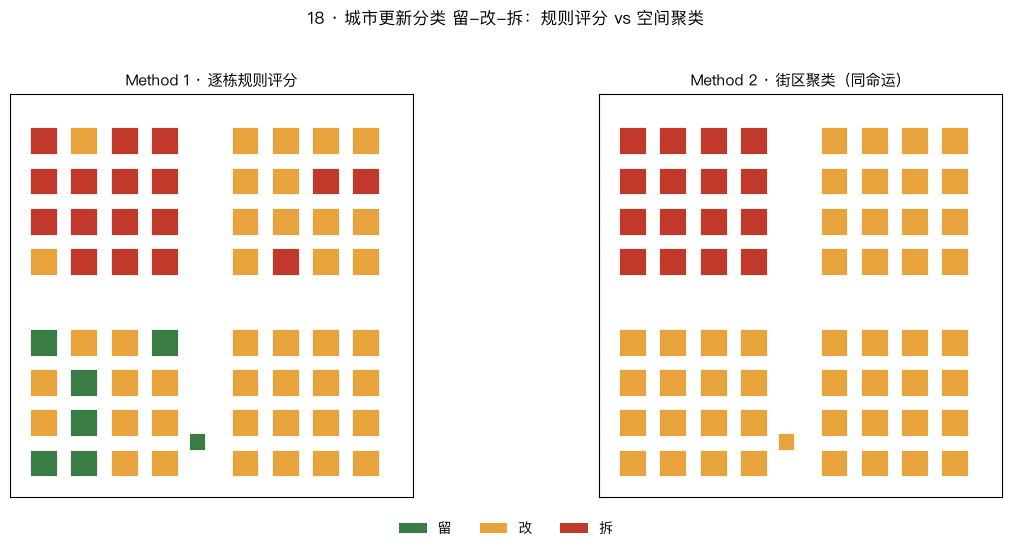

In [5]:
# --- figure 1: Method 1 (per building) vs Method 2 (clustered) -------------
colors = {"retain": "#3a7d44", "renovate": "#e8a33d", "demolish": "#c0392b"}
BLOCK_ORIGIN = {"B0": (0, 0), "B1": (150, 0), "B2": (0, 150), "B3": (150, 150)}


def _draw_blocks(ax, buildings, treatments):
    for g, t in zip(buildings, treatments):
        x0, y0, x1, y1 = g.bounds
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                               facecolor=colors[t], edgecolor="white", lw=0.6))
    ax.set_xlim(-15, 285)
    ax.set_ylim(-15, 285)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.4))
_draw_blocks(ax1, buildings, treat_m1)
ax1.set_title("Method 1 · 逐栋规则评分", fontsize=11)
_draw_blocks(ax2, buildings, treat_m2)
ax2.set_title("Method 2 · 街区聚类（同命运）", fontsize=11)
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[t])
           for t in TREATMENT_ORDER]
fig.legend(handles, [TREATMENT_ZH[t] for t in TREATMENT_ORDER],
           loc="lower center", ncol=3, frameon=False, fontsize=10)
fig.suptitle("18 · 城市更新分类 留-改-拆：规则评分 vs 空间聚类", fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
fig.savefig(OUTPUTS / "18-renewal-rule-vs-cluster.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Method 3 — Capacity-based renewal 容量评估

开发容量视角：现状容积率相对规划容积率越低，拆除重建的开发收益越大。

`ratio = 现状FAR / 规划FAR`

- `ratio < 0.5`       → **拆**（大规模重建，开发价值显著）
- `0.5 <= ratio < 0.8` → **改**（功能 / 容量局部升级）
- `ratio >= 0.8`      → **留**（容量已接近规划，保留 + 提质）

以街区为单元：`block FAR = Σ(基底面积 × 层数) / 街区用地面积`
（本场地街区用地 120×120 m = 14,400 m²，每栋基底 20×20 = 400 m²）。
规划 FAR 按控规参考值假设：B0 = 2.5, B1 = 2.5, B2 = 3.0, B3 = 2.0。


In [6]:
FOOTPRINT = 400.0          # 20 x 20 m
BLOCK_LAND = 14400.0       # 120 x 120 m
planned_far = {"B0": 2.5, "B1": 2.5, "B2": 3.0, "B3": 2.0}

current_far = {}
for b in planned_far:
    floors = sum(r["floors"] for r in records
                 if r["block"] == b and not r["kiosk"])
    current_far[b] = floors * FOOTPRINT / BLOCK_LAND

m3 = {b: capacity_assessment(current_far[b], planned_far[b])
      for b in planned_far}

print(f"{'block':<6}{'curFAR':>8}{'planFAR':>9}{'ratio':>8}  {'treatment':>9}")
for b in planned_far:
    r = m3[b]
    print(f"{b:<6}{current_far[b]:>8.2f}{planned_far[b]:>9.2f}{r['ratio']:>8.2f}"
          f"  {TREATMENT_ZH[r['treatment']]:>9}")


block   curFAR  planFAR   ratio  treatment
B0        2.39     2.50    0.96          留
B1        1.69     2.50    0.68          改
B2        1.39     3.00    0.46          拆
B3        1.56     2.00    0.78          改


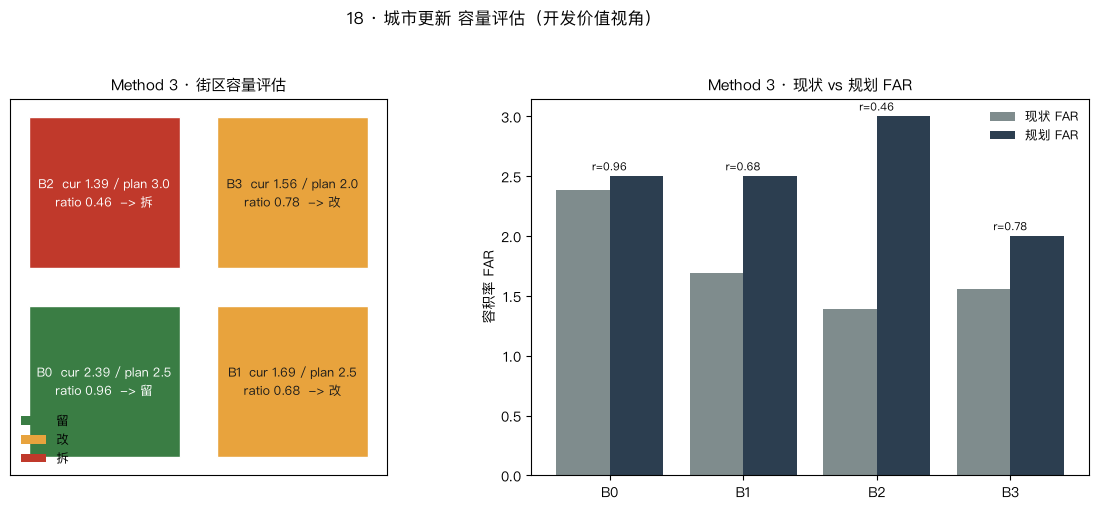

In [7]:
# --- figure 2: Method 3 capacity map + current-vs-planned FAR bars ---------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2))
for b in planned_far:
    ox, oy = BLOCK_ORIGIN[b]
    t = m3[b]["treatment"]
    ax1.add_patch(Rectangle((ox, oy), 120, 120, facecolor=colors[t],
                            edgecolor="white", lw=1))
    txt = (f"{b}  cur {current_far[b]:.2f} / plan {planned_far[b]:.1f}\n"
           f"ratio {m3[b]['ratio']:.2f}  -> {TREATMENT_ZH[t]}")
    ax1.text(ox + 60, oy + 60, txt, ha="center", va="center", fontsize=9,
             color="#1a1a1a" if t == "renovate" else "white")
ax1.set_xlim(-15, 285)
ax1.set_ylim(-15, 285)
ax1.set_aspect("equal")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title("Method 3 · 街区容量评估", fontsize=11)
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[t])
           for t in TREATMENT_ORDER]
ax1.legend(handles, [TREATMENT_ZH[t] for t in TREATMENT_ORDER],
           loc="lower left", frameon=False, fontsize=9)

x = np.arange(len(planned_far))
names = list(planned_far)
ax2.bar(x - 0.2, [current_far[b] for b in names], 0.4,
        label="现状 FAR", color="#7f8c8d")
ax2.bar(x + 0.2, [planned_far[b] for b in names], 0.4,
        label="规划 FAR", color="#2c3e50")
for xi, b in zip(x, names):
    ax2.text(xi, max(current_far[b], planned_far[b]) + 0.05,
             f"r={m3[b]['ratio']:.2f}", ha="center", fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(names)
ax2.set_ylabel("容积率 FAR")
ax2.set_title("Method 3 · 现状 vs 规划 FAR", fontsize=11)
ax2.legend(frameon=False, fontsize=9)

fig.suptitle("18 · 城市更新 容量评估（开发价值视角）", fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
fig.savefig(OUTPUTS / "18-renewal-capacity.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Comparison and Conclusions 三方法对比

| 方法 | 输入 | 单元 | 输出 | 视角 |
|---|---|---|---|---|
| M1 规则评分 | 年代 / 结构 / 用途 | 单栋 | 留/改/拆 | 建筑质量与年限 |
| M2 空间聚类 | M1 分数 + 几何 | 街区簇 | 整簇统一处理 | 空间连贯性 |
| M3 容量评估 | 现状 / 规划 FAR | 街区 | 留/改/拆 | 开发容量 |


In [8]:
# --- block-level comparison ------------------------------------------------
print(f"{'block':<6}{'M1多数':>8}{'M2':>5}{'M3':>5}{'curFAR':>8}"
      f"{'planFAR':>8}{'ratio':>7}")
m2_block = {}
for b in planned_far:
    idx = np.array([r["block"] == b and not r["kiosk"] for r in records])
    m1_major = max(TREATMENT_ORDER,
                   key=lambda t: int(np.sum(treat_m1[idx] == t)))
    m2_block[b] = treat_m2[idx][0]          # uniform within cluster
    r = m3[b]
    print(f"{b:<6}{TREATMENT_ZH[m1_major]:>8}{TREATMENT_ZH[m2_block[b]]:>5}"
          f"{TREATMENT_ZH[r['treatment']]:>5}{current_far[b]:>8.2f}"
          f"{planned_far[b]:>8.2f}{r['ratio']:>7.2f}")

agree = sum(1 for b in planned_far if m2_block[b] == m3[b]["treatment"])
print(f"\nblock-level agreement M2 vs M3: {agree} / {len(planned_far)}")
print(f"treatments flipped by clustering (M1 -> M2): {n_flip} / {len(buildings)}")
print(f"isolated demolition candidates: M1 = {iso1}  ->  M2 = {iso2}")
print("demolish buildings: "
      f"M1 = {int(np.sum(treat_m1 == 'demolish'))}  ->  "
      f"M2 = {int(np.sum(treat_m2 == 'demolish'))}")

# 条例仲裁：方法分歧时取更保守（保留优先）的判定
final_decision = {}
for b in planned_far:
    if m2_block[b] != m3[b]["treatment"]:
        final_decision[b] = "retain" if "retain" in (m2_block[b], m3[b]["treatment"])             else min((m2_block[b], m3[b]["treatment"]),
                     key=lambda t: TREATMENT_ORDER.index(t))
    else:
        final_decision[b] = m2_block[b]
print()
print("arbitrated final decision (M2 vs M3 conflict -> 保留优先):")
print("  " + "  ".join(f"{b}: {TREATMENT_ZH[t]}" for b, t in final_decision.items()))
print()
print("summary: isolated demolitions M1 -> M2: "
      f"{iso1} -> {iso2}; flipped by clustering: {n_flip} / {len(buildings)}")


block     M1多数   M2   M3  curFAR planFAR  ratio
B0           改    改    留    2.39    2.50   0.96
B1           改    改    改    1.69    2.50   0.68
B2           拆    拆    拆    1.39    3.00   0.46
B3           改    改    改    1.56    2.00   0.78

block-level agreement M2 vs M3: 3 / 4
treatments flipped by clustering (M1 -> M2): 12 / 65
isolated demolition candidates: M1 = 1  ->  M2 = 0
demolish buildings: M1 = 17  ->  M2 = 16

arbitrated final decision (M2 vs M3 conflict -> 保留优先):
  B0: 留  B1: 改  B2: 拆  B3: 改

summary: isolated demolitions M1 -> M2: 1 -> 0; flipped by clustering: 12 / 65


### 结论

1. **三个方法回答三个问题**：M1 问"这栋楼还能不能留"（物理质量），M2 问
   "拆它会不会破坏街区"（空间连贯），M3 问"拆了重盖值不值"（开发容量）。
   单靠任何一个都会偏。
2. **M2 是决策落地层**：逐栋结果必须经过空间聚类才可实施 —— 本场地
   M1 中的独栋拆除候选经聚类后全部并入相邻街区多数处理（数量见上表：
   独栋拆除 M1 -> M2），拆除集中在成片街区。
3. **条例原则 = 冲突仲裁规则**：留改拆并举、以保留利用提升为主 ——
   方法分歧时取更保守（保留优先）的判定。
4. **参数敏感（C 类）**：30 年 / 15 年 / score 阈值 / ratio 0.5–0.8 全部是
   参考值，直接决定结果分布；正式使用必须与规划主管部门标定并写入
   assumptions.json。

**References**
- 《北京市城市更新条例》(2022年11月25日市十五届人大常委会第四十五次会议
  通过，2023年3月1日施行)
- 《关于在实施城市更新行动中防止大拆大建问题的通知》(建科〔2021〕63号) —
  以保留利用提升为主
